# FWI — Pearson Correlation — GFDL-ESM4 (Thailand)

Reads precomputed area-weighted annual means from the `GFDL-ESM4_FWI_Compute.ipynb` cache and computes Pearson *r*, OLS slope, and intercept between FWI and each climate driver (tasmax, pr, sfcWind, hurs), both per-scenario and pooled across all scenarios. Visualises results as a correlation heatmap.

**Study region:** Thailand (5.5–20.5°N, 97.5–105.5°E)  
**Scenarios:** historical + SSP1-1.9 / 1-2.6 / 2-4.5 / 3-7.0 / 5-8.5

## 1  Dependencies

Import `numpy`, `xarray`, `scipy.stats`, `matplotlib`, and `pathlib`.

In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
from pathlib import Path
from scipy.stats import pearsonr, linregress
import seaborn as sns


## 2  Configuration

Set `CACHE_DIR` to the directory written by `GFDL-ESM4_FWI_Compute.ipynb` and define the list of SSP scenarios.

In [5]:
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")

SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]

SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0",
    "ssp585": "SSP5-8.5",
}


## 3  Pearson Correlation and Heatmap

Compute pooled and per-scenario Pearson *r* between FWI and each driver; produce a heatmap and a table of r / slope / intercept values.

### 3a  Correlation Heatmap

Plot a colour-coded heatmap where each cell shows the pooled Pearson *r* between FWI and one driver variable across all scenarios.

In [8]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.ticker
import matplotlib.pyplot as plt


# ── Matplotlib-style heatmap helpers ──────────────────────────────────────────

def heatmap(data, row_labels, col_labels, ax=None, cbar_kw=None, cbarlabel="", **kwargs):
    if ax is None:
        ax = plt.gca()
    if cbar_kw is None:
        cbar_kw = {}

    im = ax.imshow(data, **kwargs)

    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    cbar.outline.set_linewidth(0.5)   # thin colorbar border

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=14)
    ax.set_yticklabels(row_labels, fontsize=14)

    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right", rotation_mode="anchor")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(len(col_labels) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(len(row_labels) + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}", textcolors=("black", "white"),
                     threshold=0.5, **textkw):
    if data is None:
        data = im.get_array()

    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val   = data[i, j]
            color = textcolors[1] if abs(val) > threshold else textcolors[0]
            text  = im.axes.text(j, i, valfmt(val, None), color=color, **kw)
            texts.append(text)
    return texts


# ── Main plot function ─────────────────────────────────────────────────────────

def plot_fwi_corr_heatmap(
    fwi_means:    dict,
    tasmax_means: dict,
    pr_means:     dict,
    wind_means:   dict,
    hurs_means: dict,
    scenarios:    list,
    labels:       dict,
    filename:     str = "fwi_correlation_matrix_GFDL-ESM4.png",
) -> None:
    corr_data = []
    for scen in scenarios:
        fwi_da  = fwi_means[scen]
        t       = fwi_da["year"]
        fwi_v   = fwi_da.values
        tas_v   = (tasmax_means[scen].sel(year=t, method="nearest") - 273.15  ).values
        pr_v    = (pr_means[scen].sel(   year=t, method="nearest") * 86_400.0).values
        wind_v  =  wind_means[scen].sel( year=t, method="nearest").values
        hurs_v = hurs_means[scen].sel(year=t, method="nearest").values

        df = pd.DataFrame({
            "FWI":        fwi_v,
            "Max Temp":   tas_v,
            "Precip":     pr_v,
            "Wind":       wind_v,
            "Humid.": hurs_v,
        }).corr()
        row      = df["FWI"].drop("FWI")
        row.name = labels.get(scen, scen)
        corr_data.append(row)

    final_corr_matrix = pd.concat(corr_data, axis=1).T
    data_arr  = final_corr_matrix.values
    row_lbls  = list(final_corr_matrix.index)
    col_lbls  = list(final_corr_matrix.columns)

    fig, ax = plt.subplots(figsize=(7, 6))

    def _fmt(x, pos):
        return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")

    im, _ = heatmap(
        data_arr, row_lbls, col_lbls, ax=ax,
        cmap="RdBu_r", vmin=-1, vmax=1,
        cbar_kw=dict(shrink=0.8, fraction=0.046, pad=0.04,
                     ticks=[-1, -0.5, 0, 0.5, 1]),
        cbarlabel="Pearson correlation (r)",
    )
    annotate_heatmap(im, data=data_arr,
                     valfmt=matplotlib.ticker.FuncFormatter(_fmt),
                     size=14, threshold=0.5,
                     textcolors=("black", "white"))

    ax.set_title("GFDL-ESM4 : FWI vs Climate Drivers", pad=20, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

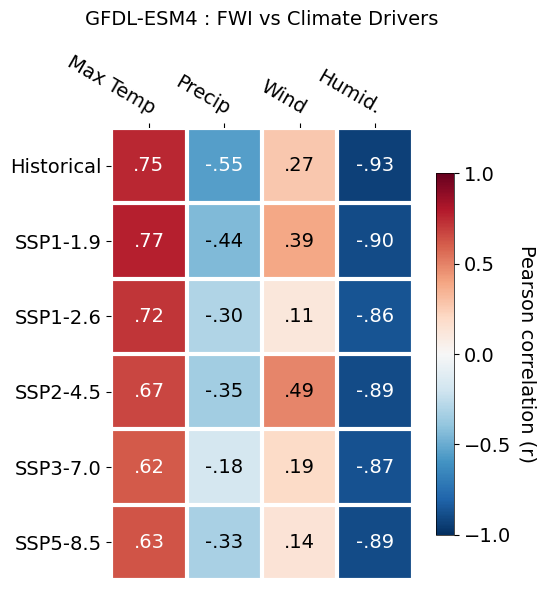

In [9]:
# ── Correlation heatmap: FWI vs 4 drivers ─────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

plot_fwi_corr_heatmap(
    fwi_means    = _ld("fwi"),
    tasmax_means = _ld("tasmax"),
    pr_means     = _ld("pr"),
    wind_means   = _ld("sfcWind"),
    hurs_means   = _ld("hurs"),
    scenarios    = SCENARIOS,
    labels       = SCENARIO_LABELS,
    filename     = "Pict/fwi_correlation_matrix_GFDL-ESM4.png",
)

### 3b  Pearson r, slope & intercept (per scenario and pooled)

For each driver variable, compute Pearson *r* (pooled over all scenarios) and per-scenario OLS slope and intercept using `scipy.stats.linregress`. Report results as a formatted table.

In [11]:
## 8  Pearson correlation, slope & intercept (driver vs FWI)
from scipy.stats import pearsonr, linregress
import pandas as pd

def pearson_driver_vs_fwi(
    fwi_means:    dict,
    driver_means: dict,
    var_label:    str,
    scenarios:    list,
    labels:       dict,
    scale:        float = 1.0,
    offset:       float = 0.0,
) -> pd.DataFrame:
    """
    Pearson r, slope, intercept between one climate driver and FWI.
    scale/offset applied to driver for unit conversion (e.g. tasmax K→°C).
    """
    combined_drv, combined_fwi = [], []
    rows = []
    for scen in scenarios:
        fwi_da = fwi_means[scen]
        t      = fwi_da["year"]
        fwi_v  = fwi_da.values
        drv_v  = (driver_means[scen].sel(year=t, method="nearest") * scale + offset).values

        mask = ~np.isnan(drv_v) & ~np.isnan(fwi_v)
        drv_v, fwi_v = drv_v[mask], fwi_v[mask]
        if len(drv_v) < 2:
            continue
        r, _                 = pearsonr(drv_v, fwi_v)
        slope, intercept, *_ = linregress(drv_v, fwi_v)
        rows.append({"Scenario": labels[scen], "r": round(r, 4),
                     "slope": round(slope, 4), "intercept": round(intercept, 4)})
        combined_drv.extend(drv_v)
        combined_fwi.extend(fwi_v)

    if combined_drv:
        r, _                 = pearsonr(combined_drv, combined_fwi)
        slope, intercept, *_ = linregress(combined_drv, combined_fwi)
        rows.append({"Scenario": "ALL (combined)", "r": round(r, 4),
                     "slope": round(slope, 4), "intercept": round(intercept, 4)})

    df = pd.DataFrame(rows)
    print(f"\n── {var_label} vs FWI — Thailand ──")
    print(df.to_string(index=False))
    return df

In [12]:
# ── Pearson correlation: FWI vs 4 drivers ────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

_fwi  = _ld("fwi")
_tas  = _ld("tasmax")
_pr   = _ld("pr")
_wind = _ld("sfcWind")
_hurs = _ld("hurs")

df_tasmax = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_tas,
    var_label="tasmax (°C)", scenarios=SCENARIOS, labels=SCENARIO_LABELS,
    scale=1.0, offset=-273.15)

df_pr = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_pr,
    var_label="pr (mm day⁻¹)", scenarios=SCENARIOS, labels=SCENARIO_LABELS,
    scale=86_400.0)

df_wind = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_wind,
    var_label="sfcWind (m s⁻¹)", scenarios=SCENARIOS, labels=SCENARIO_LABELS)

df_hurs = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_hurs,
    var_label="hurs (%)", scenarios=SCENARIOS, labels=SCENARIO_LABELS)


── tasmax (°C) vs FWI — Thailand ──
      Scenario      r  slope  intercept
    Historical 0.7510 7.1931  -179.9720
      SSP1-1.9 0.7748 7.8510  -203.4908
      SSP1-2.6 0.7182 5.8703  -147.8194
      SSP2-4.5 0.6654 5.0255  -124.0146
      SSP3-7.0 0.6157 3.2053   -72.0587
      SSP5-8.5 0.6325 2.7398   -58.8691
ALL (combined) 0.5859 2.7400   -57.2842

── pr (mm day⁻¹) vs FWI — Thailand ──
      Scenario       r   slope  intercept
    Historical -0.5518 -5.3564    47.9402
      SSP1-1.9 -0.4421 -5.1712    48.4623
      SSP1-2.6 -0.3017 -3.0398    37.4454
      SSP2-4.5 -0.3513 -3.6968    41.1522
      SSP3-7.0 -0.1760 -1.7849    31.3523
      SSP5-8.5 -0.3265 -3.7050    41.3401
ALL (combined) -0.4011 -4.2109    43.1573

── sfcWind (m s⁻¹) vs FWI — Thailand ──
      Scenario      r   slope  intercept
    Historical 0.2720 16.1811   -26.9306
      SSP1-1.9 0.3872 25.9331   -56.1072
      SSP1-2.6 0.1132  5.8874     4.2726
      SSP2-4.5 0.4910 24.6035   -52.8979
      SSP3-7.0 0.1905 

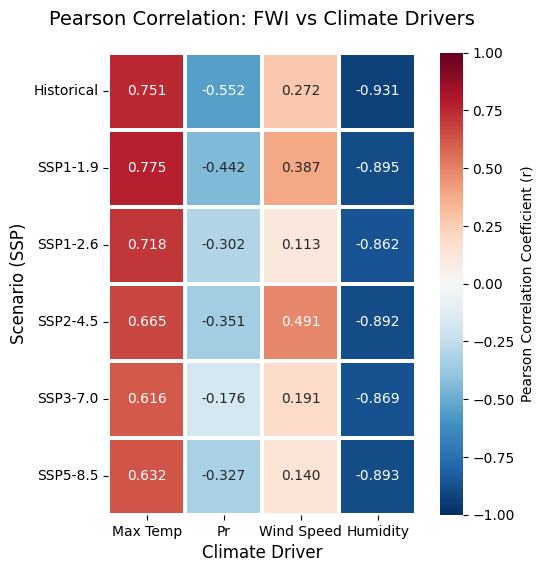

In [13]:
# 1. List your existing DataFrames and their corresponding variable names
dfs = [df_tasmax, df_pr, df_wind, df_hurs]
var_names = ["Max Temp", "Pr", "Wind Speed", "Humidity"]

# 2. Extract and combine
combined_r = []
for df, name in zip(dfs, var_names):
    s = df.set_index("Scenario")["r"]
    s.name = name  
    combined_r.append(s)

master_corr_matrix = pd.concat(combined_r, axis=1)
master_corr_matrix = master_corr_matrix.drop("ALL (combined)", errors='ignore')

# 3. Plot the Heatmap with fixed scale -1 to 1
plt.figure(figsize=(6, 6))
sns.heatmap(
    master_corr_matrix, 
    annot=True, 
    cmap="RdBu_r", 
    center=0, 
    vmin=-1,          # Force scale start at -1
    vmax=1,           # Force scale end at 1
    fmt=".3f", 
    linewidths=1.5,
    square=True,      # Makes cells square-shaped
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

plt.title("Pearson Correlation: FWI vs Climate Drivers", fontsize=14, pad=20)
plt.ylabel("Scenario (SSP)", fontsize=12)
plt.xlabel("Climate Driver", fontsize=12)

# Optional: Rotate scenario labels for better readability
plt.yticks(rotation=0)
plt.show()